# Import packages

In [1]:
import polars as pl
from pathlib import Path
import numpy as np
import pandas as pd
import polars.selectors as cs
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import fdrcorrection
from src2.utils import print_df
import os
from importlib import reload

# Define functions

## Data preprocessing functions

In [2]:
def get_combined(sample_sheet):
    all_files = [Path(SJ_file) for SJ_file in sample_sheet["path"]]
    non_empty_files = [f for f in all_files if os.path.getsize(f) > 0]

    combined = pl.scan_csv(
            non_empty_files,
            separator="\t", has_header= False, 
            new_columns=["chrom", "start", "end", "strand", "motif", "annotated", "unique_reads", "multi_reads", "max_overhang"],
            schema_overrides={"chrom": pl.String},
            include_file_paths = "path"
        ).collect()\
        .filter(
            pl.col("unique_reads")!=0
        )\
        .group_by("chrom", "start", "end", "strand", "path")\
        .agg(
            pl.col("motif").first(),
            pl.col("annotated").first(),
            unique=pl.col("unique_reads").sum(),
            multi=pl.col("multi_reads").first(),
            max_overhang=pl.col("max_overhang").first(),
        )\
        .select("path", pl.selectors.exclude("path"))\
        .join(
            sample_sheet,
            on="path",
            how="left"
        )\
        .drop("path")\
        .select("cell_name", "cell_type_label", pl.selectors.exclude("cell_name", "cell_type_label"))\
        .with_columns(
            pl.col("start").cast(pl.String),
            pl.col("end").cast(pl.String),
            pl.col("strand").cast(pl.String)
        )\
        .with_columns(
            pl.col("strand").replace({1: "+", 2: "-"})
        )
    return combined

def filter_uncannonical_introns(combined):
    combined = combined.filter(
        ~((pl.col("annotated") == 0) & (pl.col("motif") != 0) & (pl.col("max_overhang") < 20))
    ).filter(
        ~((pl.col("annotated") == 0) & (pl.col("motif") == 0) & (pl.col("max_overhang") < 30))
    )
    return combined

def add_SJ_and_SJ_group_label(combined, sharing="end"):
    if sharing == "end":
        out = combined.with_columns(
            SJ = pl.col("chrom") + pl.lit(":") + pl.col("end") + pl.lit("_") + pl.col("strand") + pl.lit("_") + pl.col("start"),
            SJ_group = pl.col("chrom") + pl.lit(":") + pl.col("end") + pl.lit("_") + pl.col("strand")
        )
    else:
        out = combined.with_columns(
            SJ = pl.col("chrom") + pl.lit(":") + pl.col("start") + pl.lit("_") + pl.col("strand") + pl.lit("_") + pl.col("end"),
            SJ_group = pl.col("chrom") + pl.lit(":") + pl.col("start") + pl.lit("_") + pl.col("strand")
        )
    return out



## Filtering functions

In [3]:
def filter_unique_SJ_per_cell(df, min_unique_SJ=10000, ):
    original_cell_count = df.unique("cell_name").shape[0]
    cells_to_keep = df.group_by("cell_name")\
        .agg(pl.col("SJ").len())\
        .filter(pl.col("SJ") >= min_unique_SJ)["cell_name"].to_list()
    removed_cell_count = original_cell_count - len(cells_to_keep)
    print(f"Filtering cells with less than {min_unique_SJ} unique SJ: {removed_cell_count} cells removed from {original_cell_count} cells.")
    return df.filter(pl.col("cell_name").is_in(cells_to_keep))

def filter_SJ_group_based_on_min_cells(df, min_cells=15):
    SJ_group_to_keep = df.group_by("SJ_group")\
        .agg(
            pl.col("cell_name").count()
        )\
        .filter(
            pl.col("cell_name") > min_cells
        )["SJ_group"].to_list()

    df = df.filter(pl.col("SJ_group").is_in(SJ_group_to_keep))
    return df

def filter_min_total_SJ_per_cell(df, min_global_counts=50000):
    original_cell_count = df.unique("cell_name").shape[0]
    cells_to_keep = df.group_by("cell_name")\
        .agg(
            pl.col("unique").sum()
        )\
        .filter(
            pl.col("unique") >= min_global_counts
        )["cell_name"].to_list()
    removed_cell_count = original_cell_count - len(cells_to_keep)
    print(f"Filtering cell with less than {min_global_counts} global unique counts: {removed_cell_count} cell removed from {original_cell_count} cell.")
    df = df.filter(pl.col("cell_name").is_in(cells_to_keep))
    return df

In [4]:
def get_ratio_matrix(df, mode="single_cell"):
    if mode == "single_cell":
        index_col = "cell_name"
    elif mode == "cell_type":
        index_col = "cell_type_label"
        # Perform the initial aggregation required for 'cell_type' mode
        df = df.group_by(index_col, "SJ").agg(
            pl.col("chrom").first(),
            pl.col("start").first(),
            pl.col("end").first(),
            pl.col("strand").first(),
            pl.col("unique").sum(),
            pl.col("SJ_group").first()
        )
    else:
        raise ValueError(f"Unknown mode: {mode}. Must be 'single_cell' or 'cell_type'.")

    ratio_matrix = df.with_columns(
        ratio = pl.col("unique") / pl.col("unique").sum().over("SJ_group", "cell_name")
    ).select(
        index_col, "SJ", "ratio"
    ).pivot(
        index=index_col,
        on="SJ",
        values="ratio"
    ).sort(index_col)

    return ratio_matrix

# Start here

In [5]:
# sample_sheet = pl.read_csv("proc/sample_sheet.csv")
# combined = get_combined(sample_sheet)

In [6]:
combined = pl.read_parquet("proc/combined_SJ.parquet")

Number of SJ removed by filtering uncannonical introns: 246737


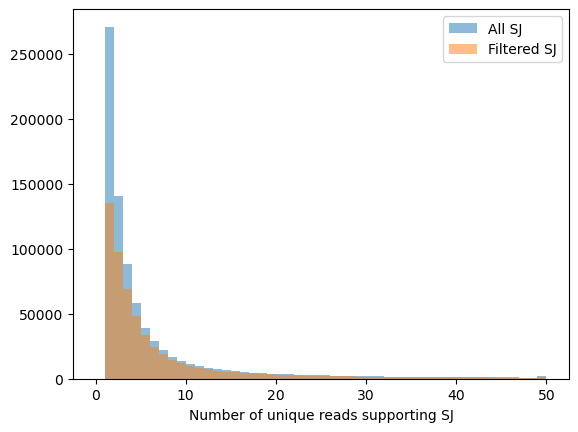

In [7]:
combined_uncanonnical_filtered = filter_uncannonical_introns(combined)
plt.hist(combined.group_by("chrom", "start", "end", "strand").agg(pl.col("unique").sum())["unique"], range=(0, 50), bins=50, alpha=0.5, label="All SJ")
plt.hist(combined_uncanonnical_filtered.group_by("chrom", "start", "end", "strand").agg(pl.col("unique").sum())["unique"], range=(0, 50), bins=50, alpha=0.5, label="Filtered SJ")
plt.xlabel("Number of unique reads supporting SJ")
plt.legend()

n_SJ_removed = combined.unique(["chrom", "start", "end", "strand"]).shape[0] - combined_uncanonnical_filtered.unique(["chrom", "start", "end", "strand"]).shape[0]
print(f"Number of SJ removed by filtering uncannonical introns: {n_SJ_removed}")

## Single cell

Text(0, 0.5, 'Number of unique SJ per cell')

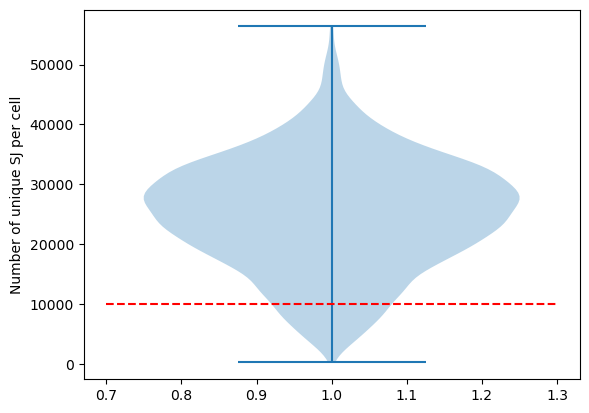

In [8]:
combined_uncanonnical_filtered\
    .group_by("cell_name")\
    .agg(pl.col("SJ").len())\
    .select("SJ")\
    .pipe(plt.violinplot)
plt.hlines(y=10000, xmin=0.7, xmax=1.3, color='r', linestyles='dashed')
plt.ylabel("Number of unique SJ per cell")

In [9]:
combined_uncanonnical_filtered = filter_unique_SJ_per_cell(combined_uncanonnical_filtered, 10000)

Filtering cells with less than 10000 unique SJ: 303 cells removed from 4355 cells.


Text(0, 0.5, 'Total number of SJ reads per cell')

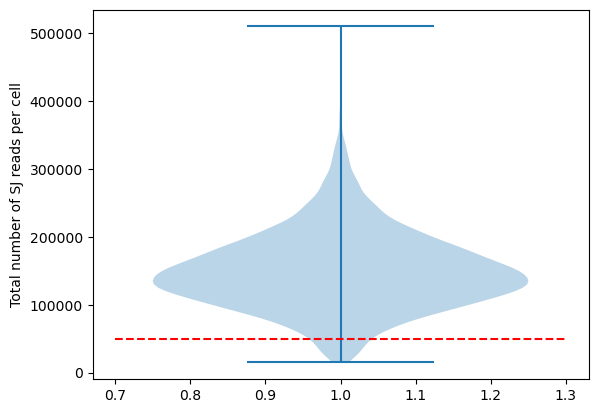

In [10]:
combined_uncanonnical_filtered\
    .group_by("cell_name")\
    .agg(pl.col("unique").sum())\
    .select("unique")\
    .pipe(plt.violinplot)
plt.hlines(y=50000, xmin=0.7, xmax=1.3, color='r', linestyles='dashed')
plt.ylabel("Total number of SJ reads per cell")

In [11]:
combined_uncanonnical_filtered = add_SJ_and_SJ_group_label(combined_uncanonnical_filtered, sharing="end")

In [12]:
combined_uncanonnical_filtered = filter_min_total_SJ_per_cell(combined_uncanonnical_filtered)

Filtering cell with less than 50000 global unique counts: 123 cell removed from 4052 cell.


In [13]:
combined_uncanonnical_filtered = combined_uncanonnical_filtered\
    .with_columns(
        pl.col("unique").sum().over("SJ_group").alias("total_unique_per_SJ_group")
    )\
    .filter(
        pl.col("total_unique_per_SJ_group") > 30
    )

In [14]:
ratio_matrix = get_ratio_matrix(combined_uncanonnical_filtered, mode="single_cell")

In [15]:
file_manifest = pl.read_csv("data/2021-09-13_mouse_file_manifest.csv")
metadata = pl.read_csv("data/20200711_patchseq_metadata_mouse.csv")
name_to_cell_specimen_id = file_manifest\
    .filter(pl.col("file_type")=="forward_fastq")\
    .with_columns(
        pl.col("file_name").str.replace("_R1.fastq.gz", "")
    )\
    .select("file_name", "cell_specimen_id")
ephys_data = pl.read_csv("data/ephys_data_sc.csv")
ephys_data = ephys_data.rename({"cell_specimen_id": "file_name"})\
    .join(
        name_to_cell_specimen_id,
        on="file_name", how="left"
    ).drop("file_name")\
    .join(
        metadata["cell_specimen_id", "T-type Label"],
        on="cell_specimen_id", how="left"
    )\
    .with_columns(
        subclass = pl.col("T-type Label").str.split(" ").map_elements(lambda x:x[0], return_dtype=pl.String)
    )\
    .drop("T-type Label")\
    .select("cell_specimen_id", "subclass", pl.selectors.exclude("cell_specimen_id", "subclass"))

In [16]:
from src2 import differential_splicing

In [18]:
res = differential_splicing.run_regression(ratio_matrix.fill_null(0.0), ephys_data.to_pandas(), "2:158218913_+", "subclass", "subclass + rheo_upstroke_downstroke_ratio")

In [ ]:
if snakemake.wildcards.model == "simple":
    reduced = "1"
    full = f"{snakemake.wildcards.predictor}"

if snakemake.wildcards.model == "multiple":
    reduced = "subclass"
    full = f"subclass + {snakemake.wildcards.predictor}"

# run in parallel
results = Parallel(n_jobs=n_jobs)(
    delayed(ds.run_regression)(adata, ig, reduced, full)
    for ig in adata.var.intron_group.unique().to_numpy()
)
df_list = [res[0] for res in results]

In [ ]:
ratio_matrix.sample()